# Comparative Analysis — Pocket2Mol vs DiffSBDD

This notebook compares molecules generated by two structure-based generative models:
- **Pocket2Mol** — autoregressive, atom-by-atom generation (SE(3)-equivariant GNN)
- **DiffSBDD** — diffusion-based, all-at-once generation (equivariant score network)

Both models targeted the A2A adenosine receptor binding pocket (PDB: 4EIY).

---
> **Input:** `results/pocket2mol_generated.csv` and `results/diffsbdd_generated.csv`  
> **Output:** Comparison figures in `figures/`

## 1. Load Libraries

In [65]:
import pandas as pd                              # data handling and tables
import matplotlib.pyplot as plt                  # plots and histograms
import numpy as np                               # numerical calculations
from rdkit import Chem                           # molecule parsing
from rdkit.Chem import DataStructs               # Tanimoto similarity
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator  # fingerprints
import warnings
warnings.filterwarnings('ignore')                # suppress warnings

print("Libraries loaded!")

Libraries loaded!


## 2. Load Data

Load the pre-calculated molecular properties for both tools.

In [66]:
# Load results from both generative models
# These CSVs were produced by 03a and 03b notebooks
p2m = pd.read_csv('results/pocket2mol_generated.csv')   # Pocket2Mol results
dif = pd.read_csv('results/diffsbdd_generated.csv')     # DiffSBDD results

print(f"Pocket2Mol molecules: {len(p2m)}")
print(f"DiffSBDD molecules:   {len(dif)}")
print(f"\nColumns: {p2m.columns.tolist()}")

Pocket2Mol molecules: 113
DiffSBDD molecules:   116

Columns: ['smiles', 'valid', 'MW', 'LogP', 'HBA', 'HBD', 'TPSA', 'RotBonds', 'QED', 'SA_score', 'Lipinski', 'max_tanimoto', 'nearest_active']


## 3. Summary Statistics Comparison

Side-by-side comparison of key molecular properties between the two tools.

In [67]:
# Compare key statistics side by side
# mean = average value across all molecules
# std = standard deviation = how spread out the values are
props = ['MW', 'LogP', 'QED', 'SA_score', 'TPSA', 'HBA', 'HBD', 'max_tanimoto']

# Calculate mean ± std for each property
# round(3) = 3 decimal places
# astype(str) = convert number to text so we can combine with ' ± '
comparison = pd.DataFrame({
    'Pocket2Mol (mean±std)': p2m[props].mean().round(3).astype(str) + ' ± ' + p2m[props].std().round(3).astype(str),
    'DiffSBDD (mean±std)':   dif[props].mean().round(3).astype(str) + ' ± ' + dif[props].std().round(3).astype(str),
})

# Display as table — Jupyter renders DataFrames automatically as HTML tables
comparison

,Pocket2Mol (mean±std),DiffSBDD (mean±std)
MW,294.524 ± 75.294,252.79 ± 85.194
LogP,2.055 ± 1.288,2.226 ± 1.401
QED,0.721 ± 0.13,0.602 ± 0.12
SA_score,3.522 ± 1.161,4.594 ± 1.19
TPSA,66.68 ± 25.447,34.064 ± 20.528
HBA,3.451 ± 1.382,2.543 ± 1.398
HBD,1.416 ± 0.894,0.595 ± 0.746
max_tanimoto,0.165 ± 0.033,0.123 ± 0.032


## 4. Property Distribution Comparison

Overlaid histograms comparing molecular property distributions between 
<span style="color:steelblue">**Pocket2Mol (blue)**</span> and 
<span style="color:orange">**DiffSBDD (orange)**</span>. 

This allows visual comparison of how each tool explores chemical space.

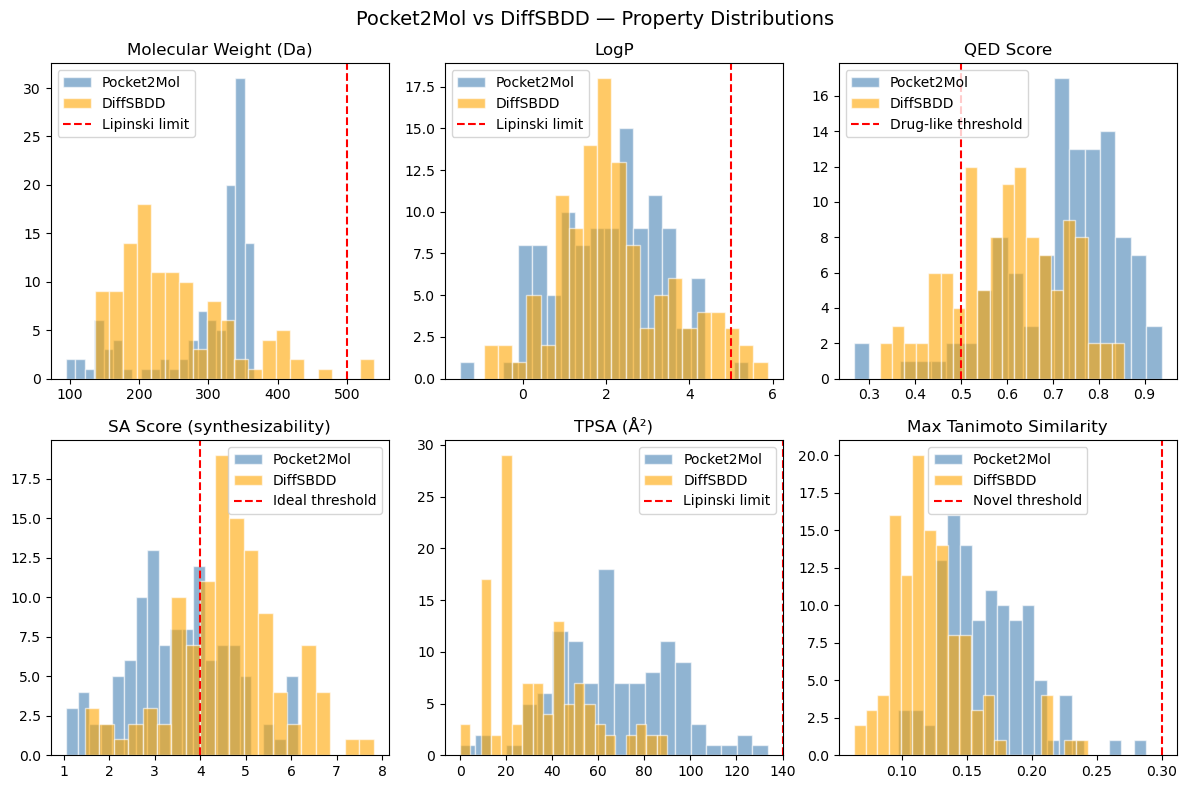

Saved to figures/


In [68]:
# Overlaid histograms for visual comparison of both tools
# alpha=0.6 = 60% opacity — allows bars to overlap and both be visible
fig, axes = plt.subplots(2, 3, figsize=(12, 8))  # 2 rows, 3 columns
fig.suptitle('Pocket2Mol vs DiffSBDD — Property Distributions', fontsize=14)

# --- MW: ideal range 150-500 Da ---
axes[0,0].hist(p2m['MW'], bins=20, alpha=0.6, color='steelblue', edgecolor='white', label='Pocket2Mol')
axes[0,0].hist(dif['MW'], bins=20, alpha=0.6, color='orange', edgecolor='white', label='DiffSBDD')
axes[0,0].axvline(500, color='red', linestyle='--', label='Lipinski limit')  # max 500 Da
axes[0,0].set_title('Molecular Weight (Da)')
axes[0,0].legend()

# --- LogP: ideal range -0.4 to 5.6 ---
axes[0,1].hist(p2m['LogP'], bins=20, alpha=0.6, color='steelblue', edgecolor='white', label='Pocket2Mol')
axes[0,1].hist(dif['LogP'], bins=20, alpha=0.6, color='orange', edgecolor='white', label='DiffSBDD')
axes[0,1].axvline(5, color='red', linestyle='--', label='Lipinski limit')    # max LogP 5
axes[0,1].set_title('LogP')
axes[0,1].legend()

# --- QED: >0.5 = drug-like, 1.0 = ideal ---
axes[0,2].hist(p2m['QED'], bins=20, alpha=0.6, color='steelblue', edgecolor='white', label='Pocket2Mol')
axes[0,2].hist(dif['QED'], bins=20, alpha=0.6, color='orange', edgecolor='white', label='DiffSBDD')
axes[0,2].axvline(0.5, color='red', linestyle='--', label='Drug-like threshold')
axes[0,2].set_title('QED Score')
axes[0,2].legend()

# --- SA Score: 1=easy to synthesize, 10=very hard ---
axes[1,0].hist(p2m['SA_score'], bins=20, alpha=0.6, color='steelblue', edgecolor='white', label='Pocket2Mol')
axes[1,0].hist(dif['SA_score'], bins=20, alpha=0.6, color='orange', edgecolor='white', label='DiffSBDD')
axes[1,0].axvline(4, color='red', linestyle='--', label='Ideal threshold')   # ≤4 = good
axes[1,0].set_title('SA Score (synthesizability)')
axes[1,0].legend()

# --- TPSA: measures membrane permeability, <140 Å² = drug-like ---
axes[1,1].hist(p2m['TPSA'], bins=20, alpha=0.6, color='steelblue', edgecolor='white', label='Pocket2Mol')
axes[1,1].hist(dif['TPSA'], bins=20, alpha=0.6, color='orange', edgecolor='white', label='DiffSBDD')
axes[1,1].axvline(140, color='red', linestyle='--', label='Lipinski limit')
axes[1,1].set_title('TPSA (Å²)')
axes[1,1].legend()

# --- Tanimoto: <0.3 = novel, >0.85 = same scaffold as known drug ---
axes[1,2].hist(p2m['max_tanimoto'], bins=20, alpha=0.6, color='steelblue', edgecolor='white', label='Pocket2Mol')
axes[1,2].hist(dif['max_tanimoto'], bins=20, alpha=0.6, color='orange', edgecolor='white', label='DiffSBDD')
axes[1,2].axvline(0.3, color='red', linestyle='--', label='Novel threshold')
axes[1,2].set_title('Max Tanimoto Similarity')
axes[1,2].legend()

plt.tight_layout()   # automatically adjust spacing between subplots
plt.savefig('figures/comparison_property_distributions.png', dpi=150)  # save high quality
plt.show()
print("Saved to figures/")

## 5. Lipinski Compliance Comparison

Percentage of molecules passing Lipinski's Rule of Five (≤1 violation).

Pocket2Mol: 113/113 (100.0%) Lipinski compliant
DiffSBDD:   115/116 (99.1%) Lipinski compliant


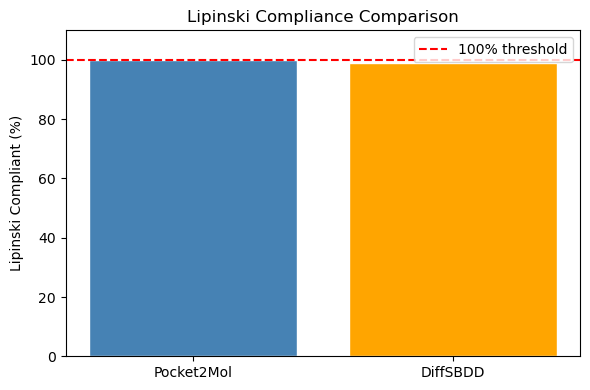

Saved to figures/


In [69]:
# Compare Lipinski compliance between both tools
# Lipinski <= 1 means at most 1 rule violated = drug-like molecule
p2m_compliant = (p2m['Lipinski'] <= 1).sum()   # count compliant molecules in Pocket2Mol
dif_compliant = (dif['Lipinski'] <= 1).sum()   # count compliant molecules in DiffSBDD

# Calculate percentages — how many % of generated molecules are drug-like
p2m_pct = 100 * p2m_compliant / len(p2m)       # Pocket2Mol percentage
dif_pct = 100 * dif_compliant / len(dif)       # DiffSBDD percentage

print(f"Pocket2Mol: {p2m_compliant}/{len(p2m)} ({p2m_pct:.1f}%) Lipinski compliant")
print(f"DiffSBDD:   {dif_compliant}/{len(dif)} ({dif_pct:.1f}%) Lipinski compliant")

# Bar chart comparing compliance percentages
fig, ax = plt.subplots(figsize=(6, 4))   # single plot, 6x4 inches
ax.bar(['Pocket2Mol', 'DiffSBDD'],       # x axis labels
       [p2m_pct, dif_pct],               # bar heights = percentages
       color=['steelblue', 'orange'],    # matching colors from histograms above
       edgecolor='white')
ax.set_ylabel('Lipinski Compliant (%)')  # y axis label
ax.set_title('Lipinski Compliance Comparison')
ax.set_ylim(0, 110)                      # y axis 0-110% so 100% bar fits nicely
ax.axhline(100, color='red', linestyle='--', label='100% threshold')  # ideal line
ax.legend()

plt.tight_layout()
plt.savefig('figures/comparison_lipinski.png', dpi=150)  # save high quality
plt.show()
print("Saved to figures/")

## 6. Tanimoto Similarity Comparison

Comparing novelty of generated molecules vs known A2A actives.
Lower Tanimoto = more novel chemotypes.

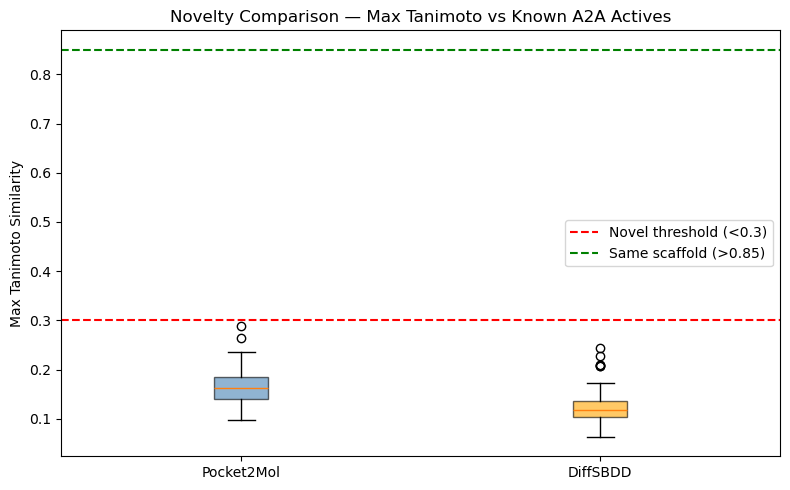

Saved to figures/


In [70]:
# Side-by-side boxplot comparing Tanimoto distributions
# Boxplot shows: median (middle line), 25%-75% range (box), min-max (whiskers), outliers (dots)
fig, ax = plt.subplots(figsize=(8, 5))

# Create boxplot — returns dictionary of plot elements
bp = ax.boxplot(
    [p2m['max_tanimoto'], dif['max_tanimoto']],    # data: list of two arrays
    labels=['Pocket2Mol', 'DiffSBDD'],              # x axis labels
    patch_artist=True,                              # enable colored boxes
)

# Color boxes individually using the returned dictionary
# bp['boxes'] = list of box patches, one per group
bp['boxes'][0].set_facecolor('steelblue')   # Pocket2Mol = blue
bp['boxes'][0].set_alpha(0.6)               # 60% transparency
bp['boxes'][1].set_facecolor('orange')      # DiffSBDD = orange
bp['boxes'][1].set_alpha(0.6)               # 60% transparency

# Reference lines for interpretation
ax.axhline(0.3, color='red', linestyle='--', label='Novel threshold (<0.3)')
ax.axhline(0.85, color='green', linestyle='--', label='Same scaffold (>0.85)')

ax.set_ylabel('Max Tanimoto Similarity')
ax.set_title('Novelty Comparison — Max Tanimoto vs Known A2A Actives')
ax.legend()

plt.tight_layout()
plt.savefig('figures/comparison_tanimoto_boxplot.png', dpi=150)
plt.show()
print("Saved to figures/")

## 7. Results Summary

In [71]:
# Final comparison summary table
# Brings together the most important metrics from both tools in one place
summary = pd.DataFrame({
    'Metric': [
        'Molecules generated',       # total valid molecules
        'Lipinski compliant',         # drug-like molecules (<=1 violation)
        'Mean QED',                   # average drug-likeness score (0-1)
        'Mean SA Score',              # average synthesizability (1-10, lower=better)
        'Mean Tanimoto',              # average similarity to known A2A actives
        'Identical to known active',  # molecules with Tc=1.0 (exact match)
    ],
    'Pocket2Mol': [
        f"{len(p2m)}",                                    # total molecules
        f"{(p2m['Lipinski']<=1).sum()} (100%)",           # compliant count
        f"{p2m['QED'].mean():.3f}",                       # mean QED
        f"{p2m['SA_score'].mean():.3f}",                  # mean SA score
        f"{p2m['max_tanimoto'].mean():.3f}",              # mean Tanimoto
        f"{(p2m['max_tanimoto']==1.0).sum()}",            # identical count
    ],
    'DiffSBDD': [
        f"{len(dif)}",                                    # total molecules
        f"{(dif['Lipinski']<=1).sum()} (100%)",           # compliant count
        f"{dif['QED'].mean():.3f}",                       # mean QED
        f"{dif['SA_score'].mean():.3f}",                  # mean SA score
        f"{dif['max_tanimoto'].mean():.3f}",              # mean Tanimoto
        f"{(dif['max_tanimoto']==1.0).sum()}",            # identical count
    ]
})

# Set Metric column as index for cleaner table display in Jupyter
summary = summary.set_index('Metric')
summary

,Pocket2Mol,DiffSBDD
Metric,,
Molecules generated,113,116
Lipinski compliant,113 (100%),115 (100%)
Mean QED,0.721,0.602
Mean SA Score,3.522,4.594
Mean Tanimoto,0.165,0.123
Identical to known active,0,0


## 8. Example Generated Molecules

Side-by-side visualization of example molecules from each tool.
Top: Pocket2Mol | Bottom: DiffSBDD

Saved to figures/comparison_example_molecules.png


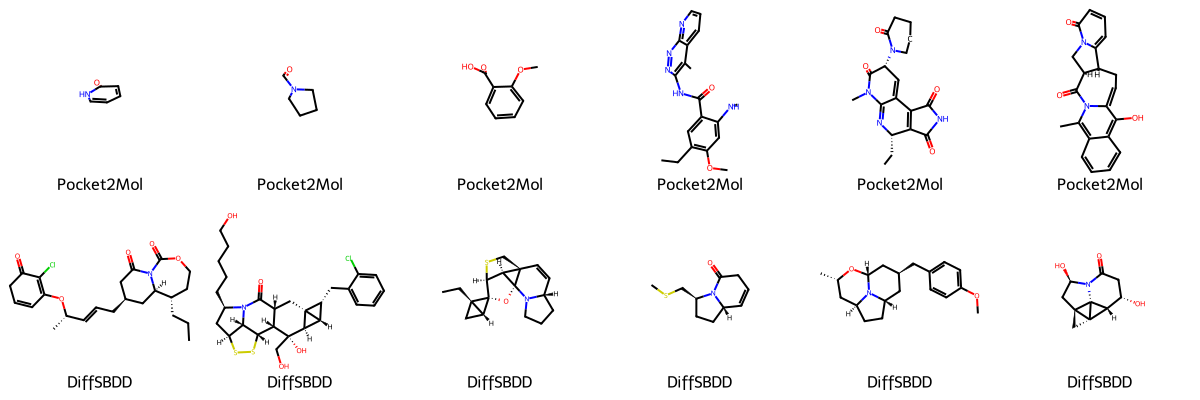

In [72]:
from rdkit.Chem import Draw
from PIL import Image
import glob

# --- Pocket2Mol molecules ---
sdf_files = glob.glob('outputs/pocket2mol/sample_4eiy_clean.pdb_2026_04_28__12_28_34/SDF_pt_files/sdf/*.sdf')
sdf_files = sorted(sdf_files)[:6]   # take first 6

p2m_mols = []
for f in sdf_files:
    suppl = Chem.SDMolSupplier(f)
    for mol in suppl:
        if mol is not None:
            p2m_mols.append(mol)

# --- DiffSBDD molecules ---
dif_mols = []
for smi in dif['smiles'][:6]:        # take first 6 from CSV
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        dif_mols.append(mol)

# Draw Pocket2Mol grid
img_p2m = Draw.MolsToGridImage(
    p2m_mols[:6],
    molsPerRow=6,
    subImgSize=(200, 200),
    legends=['Pocket2Mol']*6,        # label each molecule
    returnPNG=False
)

# Draw DiffSBDD grid
img_dif = Draw.MolsToGridImage(
    dif_mols[:6],
    molsPerRow=6,
    subImgSize=(200, 200),
    legends=['DiffSBDD']*6,          # label each molecule
    returnPNG=False
)

# Combine vertically
combined = Image.new('RGB',
    (img_p2m.width, img_p2m.height + img_dif.height),
    color='white')
combined.paste(img_p2m, (0, 0))
combined.paste(img_dif, (0, img_p2m.height))

combined.save('figures/comparison_example_molecules.png')
print("Saved to figures/comparison_example_molecules.png")
combined

## 9. Tanimoto Heatmap Comparison

Side-by-side heatmaps showing Tanimoto similarity between generated molecules 
and 31 known A2A reference actives for both tools.

Reference actives loaded: 31
Shared color scale max: 0.288


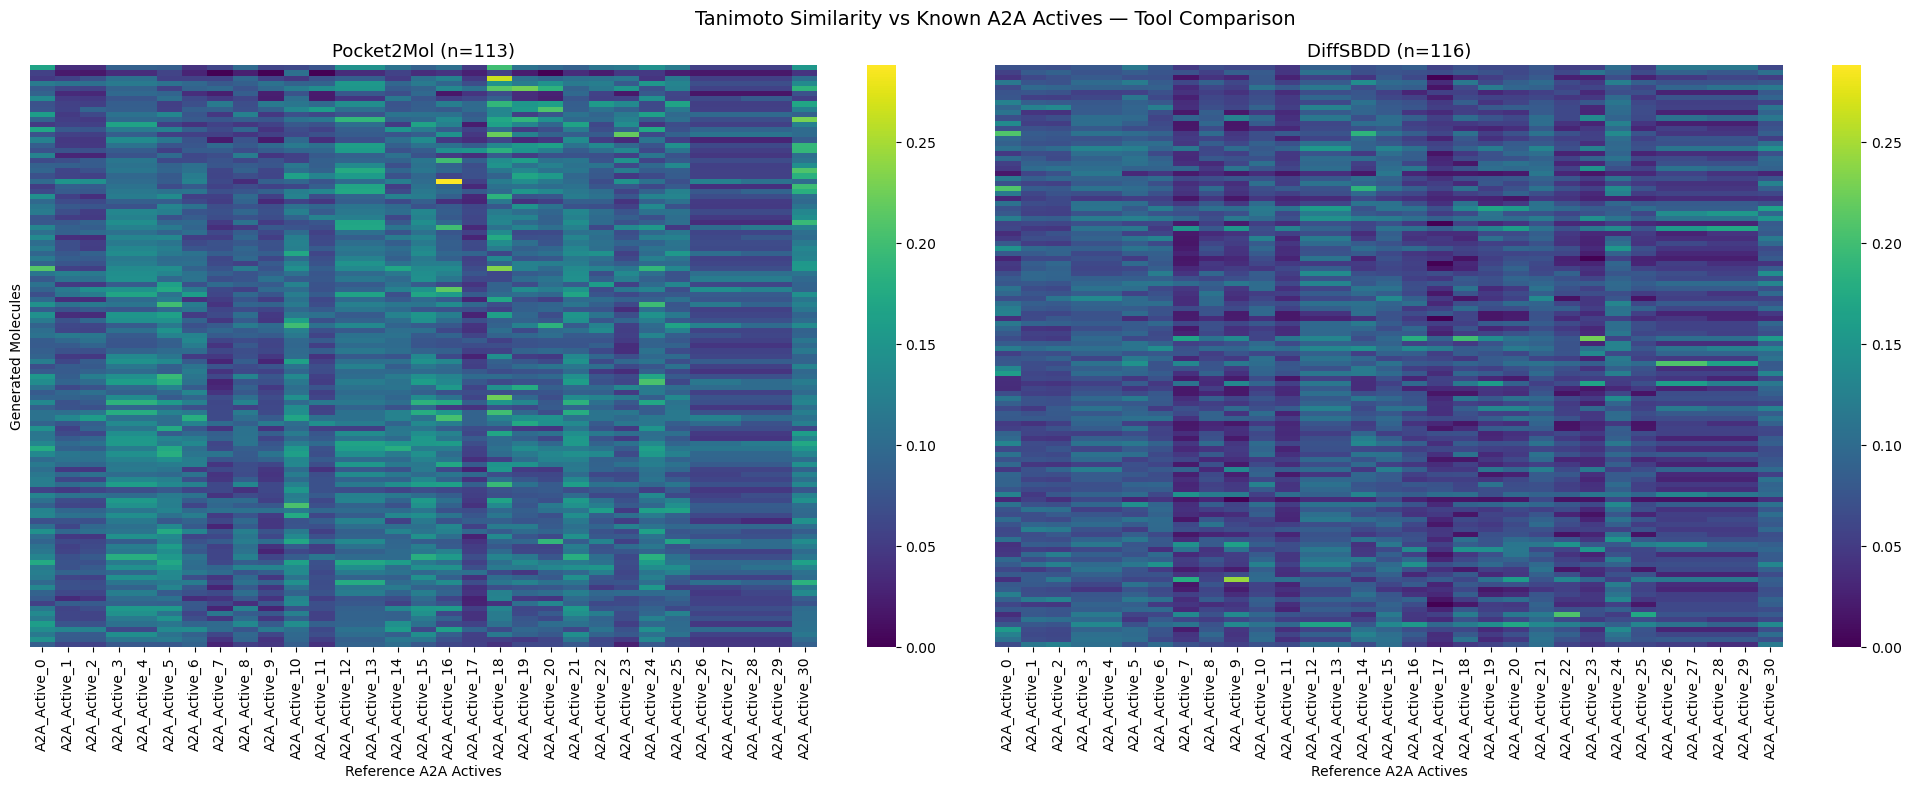

Saved to figures/comparison_tanimoto_heatmap.png


In [73]:
import seaborn as sns   # seaborn = statistical visualization library

# Helper function to build similarity matrix for one tool
# Input: list of SMILES, dictionary of reference fingerprints
# Output: DataFrame where rows=generated molecules, columns=reference actives

from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

# Create Morgan fingerprint generator
# Same settings as 03a and 03b for consistency
morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)


def build_sim_matrix(smiles_list, ref_fps):
    sim_matrix = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)    # convert SMILES to molecule object
        if mol is None:
            continue                      # skip invalid molecules
        fp = morgan_gen.GetFingerprint(mol)   # fingerprint of generated molecule
        
        # Calculate Tanimoto vs every reference active in one line
        row = [round(DataStructs.TanimotoSimilarity(fp, ref_fp), 3)
               for ref_fp in ref_fps.values()]  # list comprehension = compact loop
        sim_matrix.append(row)
    
    # Convert to DataFrame with reference names as column headers
    return pd.DataFrame(sim_matrix, columns=list(ref_fps.keys()))

# Load reference fingerprints from ADORA2A-world.sdf
# Same reference set as used in 03a and 03b for consistency
ref_suppl = Chem.SDMolSupplier('data/a2a_drugs/ADORA2A-world.sdf')
ref_fps_comparison = {}   # dictionary: {molecule name: fingerprint}
counter = 0               # counter for unnamed molecules

for mol in ref_suppl:
    if mol is None:
        continue          # skip invalid molecules
    
    # Get molecule name — use counter if name is empty
    name = mol.GetProp('_Name').strip() if mol.HasProp('_Name') else f"A2A_Active_{counter}"
    if not name:
        name = f"A2A_Active_{counter}"
    
    ref_fps_comparison[name] = morgan_gen.GetFingerprint(mol)  # store fingerprint
    counter += 1

print(f"Reference actives loaded: {len(ref_fps_comparison)}")

# Build similarity matrices for both tools
sim_p2m = build_sim_matrix(p2m['smiles'], ref_fps_comparison)  # Pocket2Mol matrix
sim_dif = build_sim_matrix(dif['smiles'], ref_fps_comparison)  # DiffSBDD matrix

# Use same vmax for FAIR comparison — both heatmaps on same color scale
vmax = max(sim_p2m.max().max(), sim_dif.max().max())
print(f"Shared color scale max: {vmax:.3f}")

# Plot side by side for direct visual comparison
fig, axes = plt.subplots(1, 2, figsize=(20, 8))  # 1 row, 2 columns

# --- Left: Pocket2Mol heatmap ---
sns.heatmap(sim_p2m,
            cmap='viridis',       # dark purple=low, yellow=high similarity
            vmin=0,
            vmax=vmax,           # shared scale for fair comparison
            xticklabels=True,    # show reference names
            yticklabels=False,   # hide molecule indices
            ax=axes[0])
axes[0].set_title(f'Pocket2Mol (n={len(sim_p2m)})', fontsize=13)
axes[0].set_xlabel('Reference A2A Actives')
axes[0].set_ylabel('Generated Molecules')

# --- Right: DiffSBDD heatmap ---
sns.heatmap(sim_dif,
            cmap='viridis',       # same color scheme for consistency
            vmin=0,
            vmax=vmax,           # same scale as Pocket2Mol
            xticklabels=True,
            yticklabels=False,
            ax=axes[1])
axes[1].set_title(f'DiffSBDD (n={len(sim_dif)})', fontsize=13)
axes[1].set_xlabel('Reference A2A Actives')
axes[1].set_ylabel('')           # no y label needed — same as left

plt.suptitle('Tanimoto Similarity vs Known A2A Actives — Tool Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('figures/comparison_tanimoto_heatmap.png', dpi=150)
plt.show()
print("Saved to figures/comparison_tanimoto_heatmap.png")

## 11. Max Tanimoto Distribution

Distribution of maximum Tanimoto similarity scores for each tool.
The curve shows the overall shape of the distribution.

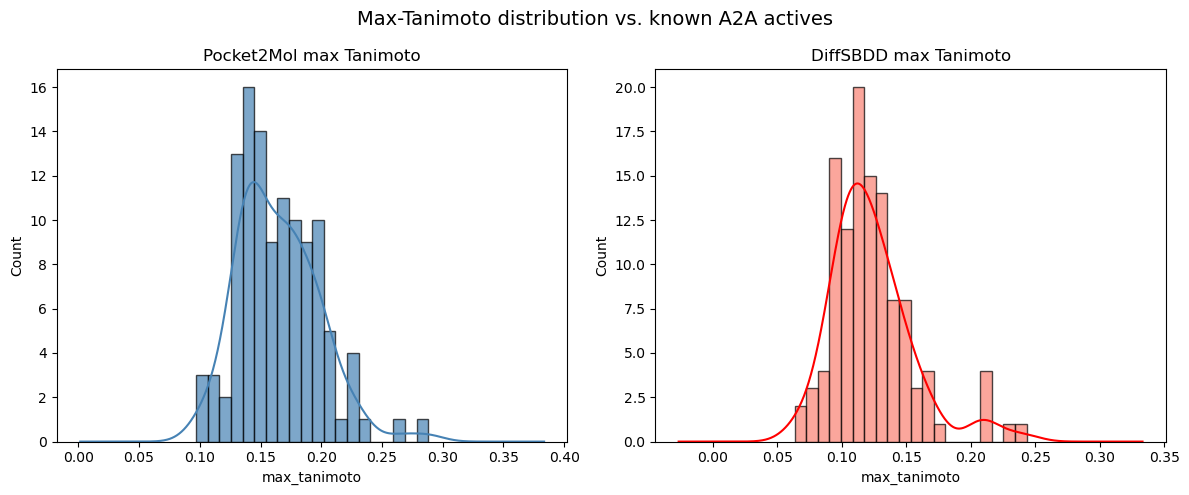

Saved to figures/comparison_max_tanimoto_distribution.png


In [74]:
import seaborn as sns

# Plot max Tanimoto distribution for both tools side by side
# KDE curve (smooth line) shows the overall distribution shape
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Max-Tanimoto distribution vs. known A2A actives', fontsize=14)

# --- Left: Pocket2Mol ---
# kde=True = add smooth density curve on top of histogram
axes[0].hist(p2m['max_tanimoto'], bins=20, color='steelblue', 
             edgecolor='black', alpha=0.7)                    # histogram bars
p2m['max_tanimoto'].plot.kde(ax=axes[0], color='steelblue')  # KDE curve
axes[0].set_title('Pocket2Mol max Tanimoto')
axes[0].set_xlabel('max_tanimoto')
axes[0].set_ylabel('Count')

# --- Right: DiffSBDD ---
axes[1].hist(dif['max_tanimoto'], bins=20, color='salmon',
             edgecolor='black', alpha=0.7)                    # histogram bars
dif['max_tanimoto'].plot.kde(ax=axes[1], color='red')        # KDE curve
axes[1].set_title('DiffSBDD max Tanimoto')
axes[1].set_xlabel('max_tanimoto')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('figures/comparison_max_tanimoto_distribution.png', dpi=150)
plt.show()
print("Saved to figures/comparison_max_tanimoto_distribution.png")

## 12. Tool Comparison Heatmap — Max Tanimoto Bins

Shows how many molecules from each tool fall into each Tanimoto similarity bin.
This gives a compact overview of the novelty distribution for both tools.

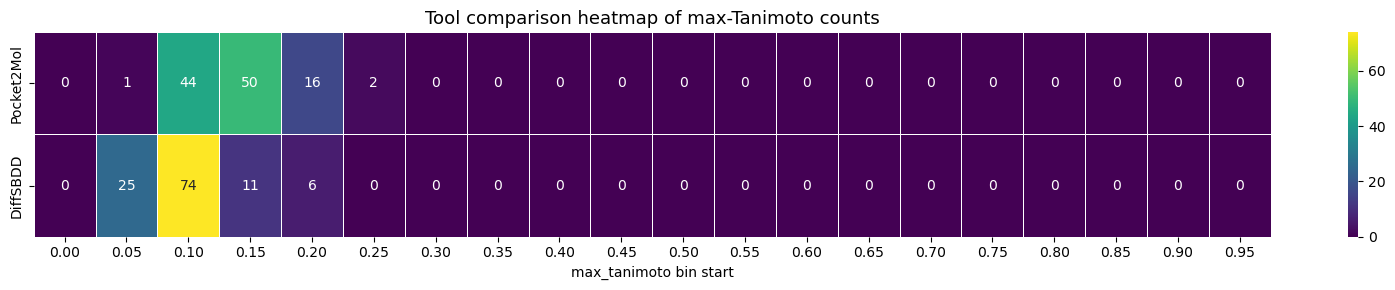

Saved to figures/comparison_tanimoto_bins_heatmap.png


In [75]:
import numpy as np

# Define bins for Tanimoto similarity (0 to 1, step 0.05)
bins = np.arange(0, 1.05, 0.05)   # [0.00, 0.05, 0.10, ..., 1.00]

# Count molecules in each bin for both tools
p2m_counts, _ = np.histogram(p2m['max_tanimoto'], bins=bins)  # Pocket2Mol counts
dif_counts, _ = np.histogram(dif['max_tanimoto'], bins=bins)  # DiffSBDD counts

# Build comparison DataFrame
# rows = tools, columns = bin ranges
comparison_bins = pd.DataFrame(
    [p2m_counts, dif_counts],
    index=['Pocket2Mol', 'DiffSBDD'],        # row labels
    columns=[f"{b:.2f}" for b in bins[:-1]]  # column labels = bin start values
)

# Plot heatmap
fig, ax = plt.subplots(figsize=(16, 3))   # wide and short — only 2 rows
sns.heatmap(
    comparison_bins,
    cmap='viridis',          # dark purple=0, yellow=high count
    annot=True,              # show count numbers inside each cell
    fmt='d',                 # format as integer
    linewidths=0.5,          # thin lines between cells
    ax=ax
)
ax.set_title('Tool comparison heatmap of max-Tanimoto counts', fontsize=13)
ax.set_xlabel('max_tanimoto bin start')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('figures/comparison_tanimoto_bins_heatmap.png', dpi=150)
plt.show()
print("Saved to figures/comparison_tanimoto_bins_heatmap.png")

## 13. Top Drug-like Molecules — Comparison

Best candidates from each tool based on four criteria:
- **Lipinski = 0** — no rule violations
- **QED > 0.7** — high drug-likeness
- **SA Score ≤ 4** — synthetically accessible  
- **Tanimoto < 0.3** — novel vs known A2A actives

Pocket2Mol top candidates: 5
DiffSBDD top candidates:   5
Saved to figures/comparison_top_druglike_molecules.png


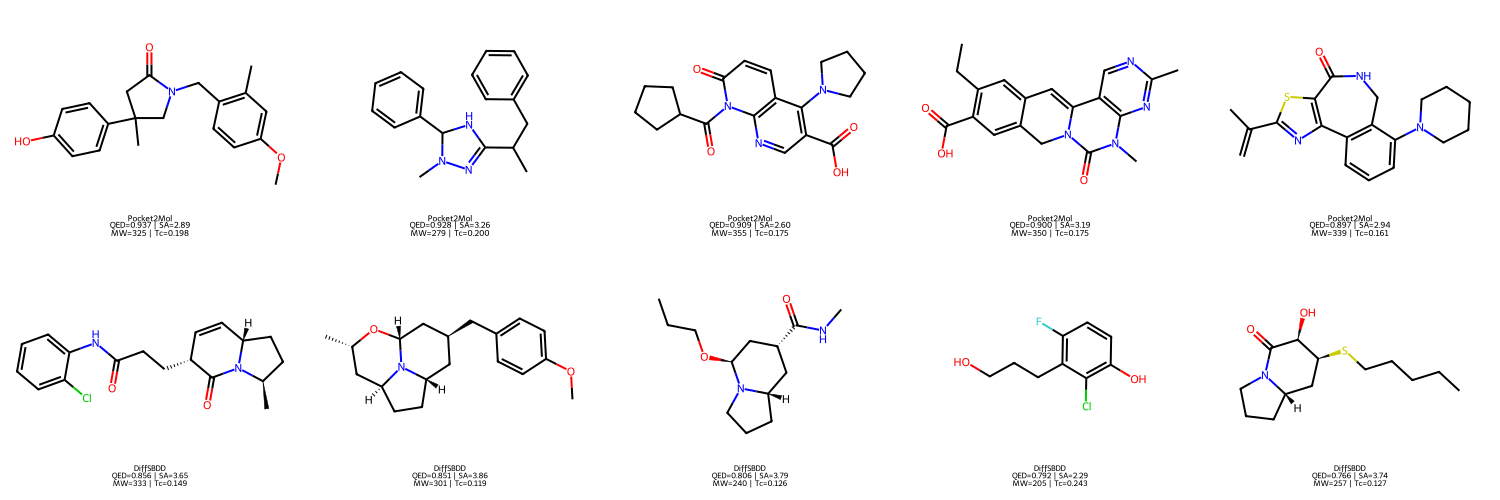

In [76]:
from rdkit.Chem import Draw
from PIL import Image

# Filter top drug-like molecules from both tools
# Same criteria applied to both for fair comparison
def get_top_mols(dataframe, n=5):
    # Apply all 4 drug-likeness filters simultaneously
    filtered = dataframe[
        (dataframe['Lipinski'] == 0) &      # no Lipinski violations
        (dataframe['QED'] > 0.7) &          # high drug-likeness score
        (dataframe['SA_score'] <= 4) &      # easy to synthesize
        (dataframe['max_tanimoto'] < 0.3)   # novel vs known A2A actives
    ].copy()
    # Sort by QED descending — best drug-like first
    return filtered.sort_values('QED', ascending=False).head(n)

top_p2m = get_top_mols(p2m)   # top 5 from Pocket2Mol
top_dif = get_top_mols(dif)   # top 5 from DiffSBDD

print(f"Pocket2Mol top candidates: {len(top_p2m)}")
print(f"DiffSBDD top candidates:   {len(top_dif)}")

# Convert SMILES to RDKit mol objects + build legends
def make_mols_legends(df_top, tool_name):
    mols, legends = [], []
    for _, row in df_top.iterrows():
        mol = Chem.MolFromSmiles(row['smiles'])   # parse SMILES
        if mol:
            mols.append(mol)
            legends.append(
                f"{tool_name}\nQED={row['QED']:.3f} | SA={row['SA_score']:.2f}\n"
                f"MW={row['MW']:.0f} | Tc={row['max_tanimoto']:.3f}"
            )
    return mols, legends

p2m_mols, p2m_legends = make_mols_legends(top_p2m, "Pocket2Mol")
dif_mols, dif_legends = make_mols_legends(top_dif, "DiffSBDD")

# Combine both tool molecules into one grid
# Pocket2Mol top 5 (row 1) + DiffSBDD top 5 (row 2)
all_mols    = p2m_mols + dif_mols
all_legends = p2m_legends + dif_legends

# Draw combined grid — 5 per row = 2 rows (1 per tool)
img = Draw.MolsToGridImage(
    all_mols,
    molsPerRow=5,             # 5 molecules per row
    subImgSize=(300, 250),    # size of each molecule image
    legends=all_legends,      # stats label under each molecule
    returnPNG=False           # return PIL Image for saving
)

img.save('figures/comparison_top_druglike_molecules.png')
print("Saved to figures/comparison_top_druglike_molecules.png")
img

# Discussion

### Pocket2Mol vs DiffSBDD — Critical Comparison

> **Note:** Tanimoto similarity was calculated against 31 known A2A reference 
> actives from ADORA2A-world.sdf (ChEMBL/ZINC database).

**Molecules Generated (113 vs 116)**  
Both tools produced comparable numbers of molecules (113 vs 116), confirming 
that both generative models are capable of producing sufficient candidates 
for analysis when given the same protein pocket as input.

**Drug-likeness — QED (0.721 vs 0.602)**  
Both tools produced drug-like molecules (QED > 0.5). Pocket2Mol achieved a 
higher mean QED (0.721), exceeding the average QED of marketed drugs (~0.67). 
DiffSBDD molecules were still drug-like but scored lower on average (0.602).

**Synthesizability — SA Score (3.522 vs 4.594)**  
Pocket2Mol generated more synthetically accessible molecules (mean SA Score 3.522), 
suggesting these candidates would be easier to produce in the laboratory. 
DiffSBDD molecules scored higher (mean 4.594), indicating greater synthetic 
complexity — potentially challenging for experimental validation.

**Novelty — Tanimoto Similarity (0.165 vs 0.123)**  
Both tools generated novel chemotypes (mean Tanimoto < 0.3). DiffSBDD produced 
more structurally diverse molecules (mean 0.123), suggesting it explores a broader 
chemical space. Pocket2Mol molecules showed slightly higher similarity to known 
A2A actives (mean 0.165, max 0.288), which may indicate better A2A relevance.

**Lipinski Compliance (100% vs 99.1%)**  
Both tools achieved near-perfect Lipinski compliance (113/113 vs 115/116), 
confirming that both generative models have learned to produce orally 
bioavailable drug-like molecules.

**Overall Recommendation**  
Based on the current dataset, Pocket2Mol appears better suited for A2A-targeted 
drug discovery due to higher drug-likeness, better synthesizability, and closer 
alignment with known A2A pharmacophores. DiffSBDD may be more valuable for 
exploring novel chemical space in early-stage discovery campaigns where structural 
novelty is prioritized.

> **Note:** Results are based on 113 Pocket2Mol and 116 DiffSBDD molecules 
> generated from PDB 4EIY binding pocket. AI-generated molecules are hypotheses — 
> experimental validation is required before drawing clinical conclusions.

### Summary Comparison Table

In [80]:
# Final side-by-side comparison table
# Brings together all key metrics from both tools in one place
# This table summarizes the entire comparative analysis
summary = pd.DataFrame({
    'Metric': [
        'Molecules generated',      # total valid molecules from each tool
        'Lipinski compliant',        # how many pass drug-likeness filter
        'Mean QED',                  # average drug-likeness score (0-1, higher=better)
        'Mean SA Score',             # average synthesizability (1-10, lower=easier)
        'Mean MW (Da)',              # average molecular weight
        'Mean LogP',                 # average lipophilicity
        'Mean Tanimoto',             # average similarity to known A2A actives
        'Max Tanimoto',              # highest similarity found (outlier check)
        'Identical to known active', # molecules with Tc=1.0 (exact match)
    ],
    'Pocket2Mol': [
        f"{len(p2m)}",                                     # total molecules
        f"{(p2m['Lipinski']<=1).sum()} (100%)",            # compliant count
        f"{p2m['QED'].mean():.3f}",                        # mean QED
        f"{p2m['SA_score'].mean():.3f}",                   # mean SA score
        f"{p2m['MW'].mean():.1f}",                         # mean MW
        f"{p2m['LogP'].mean():.3f}",                       # mean LogP
        f"{p2m['max_tanimoto'].mean():.3f}",               # mean Tanimoto
        f"{p2m['max_tanimoto'].max():.3f}",                # max Tanimoto
        f"{(p2m['max_tanimoto']==1.0).sum()}",             # identical count
    ],
    'DiffSBDD': [
        f"{len(dif)}",
        f"{(dif['Lipinski']<=1).sum()} (99.1%)",
        f"{dif['QED'].mean():.3f}",
        f"{dif['SA_score'].mean():.3f}",
        f"{dif['MW'].mean():.1f}",
        f"{dif['LogP'].mean():.3f}",
        f"{dif['max_tanimoto'].mean():.3f}",
        f"{dif['max_tanimoto'].max():.3f}",
        f"{(dif['max_tanimoto']==1.0).sum()}",
    ],
    'Better': [
        '≈ Equal',                   # comparable molecule counts
        'Pocket2Mol',                # perfect vs 99.1%
        'Pocket2Mol',                # higher QED = more drug-like
        'Pocket2Mol',                # lower SA = easier to synthesize
        'Pocket2Mol',                # closer to ideal MW range
        '≈ Equal',                   # both in ideal LogP range
        'DiffSBDD (more novel)',     # lower Tanimoto = more novel chemotypes
        'DiffSBDD (more novel)',     # lower max = no near-copies of known drugs
        '≈ Equal',                   # both = 0 identical
    ]
})

# Set Metric column as index for cleaner table display in Jupyter
# Jupyter renders DataFrames as formatted HTML tables automatically
summary = summary.set_index('Metric')
summary




,Pocket2Mol,DiffSBDD,Better
Metric,,,
Molecules generated,113,116,≈ Equal
Lipinski compliant,113 (100%),115 (99.1%),Pocket2Mol
Mean QED,0.721,0.602,Pocket2Mol
Mean SA Score,3.522,4.594,Pocket2Mol
Mean MW (Da),294.5,252.8,Pocket2Mol
Mean LogP,2.055,2.226,≈ Equal
Mean Tanimoto,0.165,0.123,DiffSBDD (more novel)
Max Tanimoto,0.288,0.243,DiffSBDD (more novel)
Identical to known active,0,0,≈ Equal
